# Cold-Start Analysis


## Inputs / outputs

Reads from Google Drive:
- `splits/{train,val,test}.csv`
- `predictions/<model>.csv` for each baseline and the hybrid

Writes to `results/` on Google Drive:
- `cold_start_user_bins.csv` — methods × user bins, RMSE values
- `cold_start_item_bins.csv` — methods × item bins, RMSE values
- `cold_start_grid.csv` — 3×3 grid: best method and hybrid's gain in each cell
- `cold_start_significance.csv` — per-bin paired Wilcoxon p-values, hybrid vs each baseline
- `cold_start_user_bins.png`, `cold_start_item_bins.png`, `cold_start_grid_heatmap.png`

No re-training required — this is a post-hoc analysis on already-saved predictions.

In [1]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [2]:
import os, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import wilcoxon

SEED = 42
random.seed(SEED); np.random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

ARTIFACT_DIR    = Path('/content/gdrive/MyDrive/recsys_artifacts')
SPLITS_DIR      = ARTIFACT_DIR / 'splits'
PREDICTIONS_DIR = ARTIFACT_DIR / 'predictions'
RESULTS_DIR     = ARTIFACT_DIR / 'results'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

## Load splits and predictions

In [3]:
train = pd.read_csv(SPLITS_DIR / 'train.csv')
test  = pd.read_csv(SPLITS_DIR / 'test.csv')
print(f'train: {len(train):,}  test: {len(test):,}')

train: 99,616  test: 610


In [4]:
# Each baseline (and the hybrid) saves test predictions to predictions/<name>.csv
MODEL_FILES = {
    'svd':         'svd.csv',
    'item_cf':     'item_cf.csv',
    'user_cf':     'user_cf.csv',
    'knn_item':    'knn_item.csv',
    'knn_user':    'knn_user.csv',
    'content':     'content_based.csv',
    'neural_cf':   'neural_cf.csv',
    'graph':       'graph.csv',
    'hybrid_gbrt': 'hybrid_gbrt.csv',
}
MODEL_ORDER = list(MODEL_FILES.keys())  # column order in tables and plots

# Start with the test ground truth, then left-join each model's predictions.
df = test[['userId', 'movieId', 'rating']].copy()
for name, fname in MODEL_FILES.items():
    path = PREDICTIONS_DIR / fname
    if not path.exists():
        print(f'  ! missing {path} — skipping {name}')
        continue
    p = pd.read_csv(path)[['userId', 'movieId', 'predicted_rating']].rename(columns={'predicted_rating': name})
    df = df.merge(p, on=['userId', 'movieId'], how='left')

# Only keep model columns that actually loaded.
MODEL_ORDER = [m for m in MODEL_ORDER if m in df.columns]
print(f'Loaded {len(MODEL_ORDER)} models:', MODEL_ORDER)
print(f'Test rows with all predictions: {df.dropna(subset=MODEL_ORDER).shape[0]} / {len(df)}')

Loaded 9 models: ['svd', 'item_cf', 'user_cf', 'knn_item', 'knn_user', 'content', 'neural_cf', 'graph', 'hybrid_gbrt']
Test rows with all predictions: 610 / 610


## Compute training activity counts and assign bins

User bins by training rating count: `cold` (<20), `medium` (20–80), `heavy` (≥80).
Item bins by training rating count: `cold` (<10), `medium` (10–50), `popular` (≥50).

These thresholds give roughly balanced bins on `ml-latest-small`.

In [5]:
user_count = train.groupby('userId').size()
item_count = train.groupby('movieId').size()

def user_bin(c):
    if c < 20:  return 'cold'
    if c < 80:  return 'medium'
    return 'heavy'

def item_bin(c):
    if c < 10:  return 'cold'
    if c < 50:  return 'medium'
    return 'popular'

df['user_bin'] = df['userId'].map(user_count).fillna(0).astype(int).apply(user_bin)
df['item_bin'] = df['movieId'].map(item_count).fillna(0).astype(int).apply(item_bin)

USER_BINS = ['cold', 'medium', 'heavy']
ITEM_BINS = ['cold', 'medium', 'popular']

print('User-bin counts on test set:')
print(df['user_bin'].value_counts().reindex(USER_BINS))
print('\nItem-bin counts on test set:')
print(df['item_bin'].value_counts().reindex(ITEM_BINS))

User-bin counts on test set:
user_bin
cold       29
medium    298
heavy     283
Name: count, dtype: int64

Item-bin counts on test set:
item_bin
cold       138
medium     225
popular    247
Name: count, dtype: int64


## Per-bin RMSE for every method

In [6]:
def rmse(y_true, y_pred):
    err = (y_true - y_pred) ** 2
    err = err[~np.isnan(err)]
    return float(np.sqrt(err.mean())) if len(err) else np.nan

def per_bin_rmse(bin_col, bin_order):
    rows = []
    for b in bin_order:
        sub = df[df[bin_col] == b]
        row = {'bin': b, 'n_test_rows': len(sub)}
        for m in MODEL_ORDER:
            row[m] = rmse(sub['rating'].values, sub[m].values)
        rows.append(row)
    return pd.DataFrame(rows).set_index('bin')

user_bin_table = per_bin_rmse('user_bin', USER_BINS)
item_bin_table = per_bin_rmse('item_bin', ITEM_BINS)

user_bin_table.to_csv(RESULTS_DIR / 'cold_start_user_bins.csv')
item_bin_table.to_csv(RESULTS_DIR / 'cold_start_item_bins.csv')

print('=== Per-user-bin RMSE ===')
print(user_bin_table.round(4))
print('\n=== Per-item-bin RMSE ===')
print(item_bin_table.round(4))

=== Per-user-bin RMSE ===
        n_test_rows     svd  item_cf  user_cf  knn_item  knn_user  content  \
bin                                                                          
cold             29  0.9296   1.2005   1.0507    0.9906    1.0365   0.9935   
medium          298  0.9696   0.9918   0.9939    1.0131    0.9890   1.0280   
heavy           283  0.9115   0.9317   0.9471    0.9181    0.9589   0.9400   

        neural_cf   graph  hybrid_gbrt  
bin                                     
cold       1.0535  1.0441       1.0284  
medium     1.0112  1.0494       0.9797  
heavy      0.9537  1.0078       0.8972  

=== Per-item-bin RMSE ===
         n_test_rows     svd  item_cf  user_cf  knn_item  knn_user  content  \
bin                                                                           
cold             138  1.0014   1.0307   1.0545    1.0285    1.0875   0.9958   
medium           225  0.9609   1.0206   0.9935    0.9982    0.9890   0.9977   
popular          247  0.8868   0.89

## 3×3 grid: best method per cell + hybrid's improvement

For each (user_bin, item_bin) intersection, find which method has the lowest RMSE (the "best baseline" if it's not the hybrid) and compute how much the hybrid improves over the best baseline.

In [7]:
baselines = [m for m in MODEL_ORDER if m != 'hybrid_gbrt']
grid_rows = []
hybrid_gain = np.full((len(USER_BINS), len(ITEM_BINS)), np.nan)

for ui, ub in enumerate(USER_BINS):
    for ii, ib in enumerate(ITEM_BINS):
        sub = df[(df['user_bin'] == ub) & (df['item_bin'] == ib)]
        if len(sub) == 0:
            grid_rows.append({'user_bin': ub, 'item_bin': ib, 'n': 0,
                              'best_baseline': None, 'best_baseline_rmse': np.nan,
                              'hybrid_rmse': np.nan, 'hybrid_gain_rmse': np.nan})
            continue
        base_rmses = {m: rmse(sub['rating'].values, sub[m].values) for m in baselines}
        best_base = min(base_rmses, key=base_rmses.get)
        h_rmse = rmse(sub['rating'].values, sub['hybrid_gbrt'].values) if 'hybrid_gbrt' in MODEL_ORDER else np.nan
        gain = base_rmses[best_base] - h_rmse if not np.isnan(h_rmse) else np.nan
        hybrid_gain[ui, ii] = gain
        grid_rows.append({
            'user_bin': ub, 'item_bin': ib, 'n': len(sub),
            'best_baseline': best_base, 'best_baseline_rmse': round(base_rmses[best_base], 4),
            'hybrid_rmse': round(h_rmse, 4) if not np.isnan(h_rmse) else np.nan,
            'hybrid_gain_rmse': round(gain, 4) if not np.isnan(gain) else np.nan,
        })

grid_df = pd.DataFrame(grid_rows)
grid_df.to_csv(RESULTS_DIR / 'cold_start_grid.csv', index=False)
print('=== 3×3 grid: best baseline + hybrid gain ===')
print(grid_df.to_string(index=False))

=== 3×3 grid: best baseline + hybrid gain ===
user_bin item_bin   n best_baseline  best_baseline_rmse  hybrid_rmse  hybrid_gain_rmse
    cold     cold   2       content              1.8348       2.3026           -0.4679
    cold   medium  13           svd              0.8797       0.9898           -0.1101
    cold  popular  14       content              0.6036       0.7237           -0.1201
  medium     cold  48       content              1.0870       1.1719           -0.0848
  medium   medium 105           svd              0.9530       0.9415            0.0115
  medium  popular 145           svd              0.9212       0.9360           -0.0148
   heavy     cold  88      knn_item              0.8830       0.9053           -0.0223
   heavy   medium 107       content              0.9776       0.9352            0.0425
   heavy  popular  88       user_cf              0.8345       0.8402           -0.0057


## Per-bin paired Wilcoxon: hybrid vs each baseline

Within each bin, test whether the hybrid's per-row squared errors are significantly different from each baseline's. With only one test interaction per user, per-row squared error is the natural per-observation metric for the paired test.

In [8]:
def squared_errors(sub, model):
    return ((sub['rating'].values - sub[model].values) ** 2)

def per_bin_wilcoxon(bin_col, bin_order):
    rows = []
    for b in bin_order:
        sub = df[df[bin_col] == b].dropna(subset=MODEL_ORDER)
        if len(sub) < 5 or 'hybrid_gbrt' not in MODEL_ORDER:
            continue
        h_se = squared_errors(sub, 'hybrid_gbrt')
        for m in baselines:
            b_se = squared_errors(sub, m)
            if np.allclose(h_se, b_se):
                stat, p = 0.0, 1.0
            else:
                stat, p = wilcoxon(h_se, b_se, zero_method='wilcox', alternative='two-sided')
            rows.append({
                'bin_dim': bin_col, 'bin': b, 'baseline': m, 'n': len(sub),
                'mean_hybrid_se': round(float(h_se.mean()), 4),
                'mean_baseline_se': round(float(b_se.mean()), 4),
                'wilcoxon_p': p,
                'sig': '**' if p < 0.01 else ('*' if p < 0.05 else ''),
            })
    return pd.DataFrame(rows)

sig_df = pd.concat([per_bin_wilcoxon('user_bin', USER_BINS), per_bin_wilcoxon('item_bin', ITEM_BINS)], ignore_index=True)
sig_df.to_csv(RESULTS_DIR / 'cold_start_significance.csv', index=False)
print('=== Per-bin Wilcoxon (hybrid vs each baseline on per-row squared error) ===')
print(sig_df.to_string(index=False))

=== Per-bin Wilcoxon (hybrid vs each baseline on per-row squared error) ===
 bin_dim     bin  baseline   n  mean_hybrid_se  mean_baseline_se  wilcoxon_p sig
user_bin    cold       svd  29          1.0576            0.8641    0.110421    
user_bin    cold   item_cf  29          1.0576            1.4412    0.304193    
user_bin    cold   user_cf  29          1.0576            1.1040    0.765542    
user_bin    cold  knn_item  29          1.0576            0.9812    0.467938    
user_bin    cold  knn_user  29          1.0576            1.0743    0.733209    
user_bin    cold   content  29          1.0576            0.9871    0.864731    
user_bin    cold neural_cf  29          1.0576            1.1098    0.781862    
user_bin    cold     graph  29          1.0576            1.0902    0.733209    
user_bin  medium       svd 298          0.9599            0.9401    0.916813    
user_bin  medium   item_cf 298          0.9599            0.9836    0.160263    
user_bin  medium   user_cf 298   

## Plots

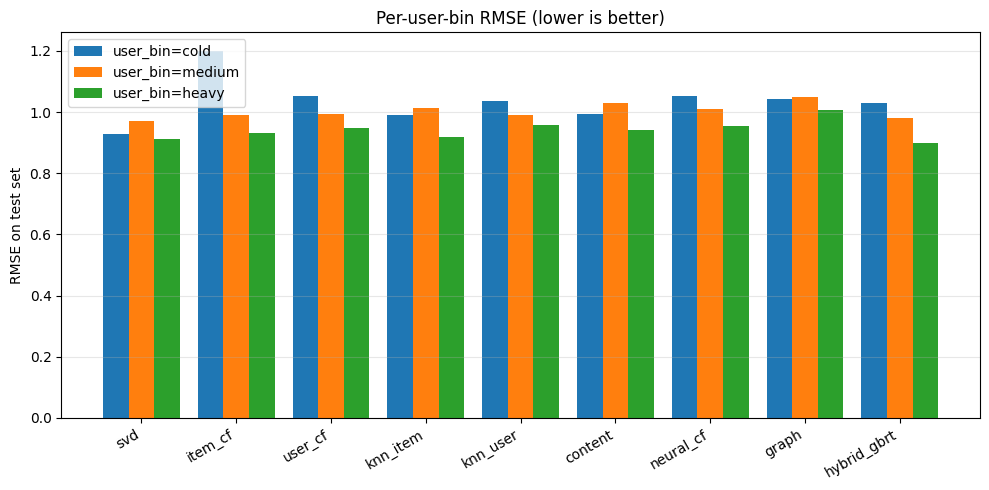

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(MODEL_ORDER))
width = 0.27
for i, b in enumerate(USER_BINS):
    vals = user_bin_table.loc[b, MODEL_ORDER].values
    ax.bar(x + (i - 1) * width, vals, width, label=f'user_bin={b}')
ax.set_xticks(x); ax.set_xticklabels(MODEL_ORDER, rotation=30, ha='right')
ax.set_ylabel('RMSE on test set'); ax.set_title('Per-user-bin RMSE (lower is better)')
ax.legend(); ax.grid(axis='y', alpha=0.3)
fig.tight_layout()
fig.savefig(RESULTS_DIR / 'cold_start_user_bins.png', dpi=150)
plt.show()

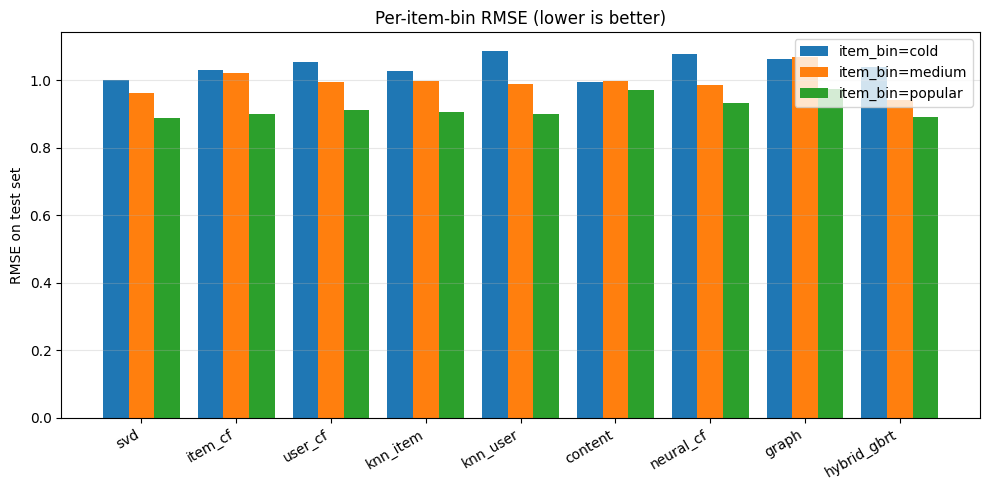

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(MODEL_ORDER))
for i, b in enumerate(ITEM_BINS):
    vals = item_bin_table.loc[b, MODEL_ORDER].values
    ax.bar(x + (i - 1) * width, vals, width, label=f'item_bin={b}')
ax.set_xticks(x); ax.set_xticklabels(MODEL_ORDER, rotation=30, ha='right')
ax.set_ylabel('RMSE on test set'); ax.set_title('Per-item-bin RMSE (lower is better)')
ax.legend(); ax.grid(axis='y', alpha=0.3)
fig.tight_layout()
fig.savefig(RESULTS_DIR / 'cold_start_item_bins.png', dpi=150)
plt.show()

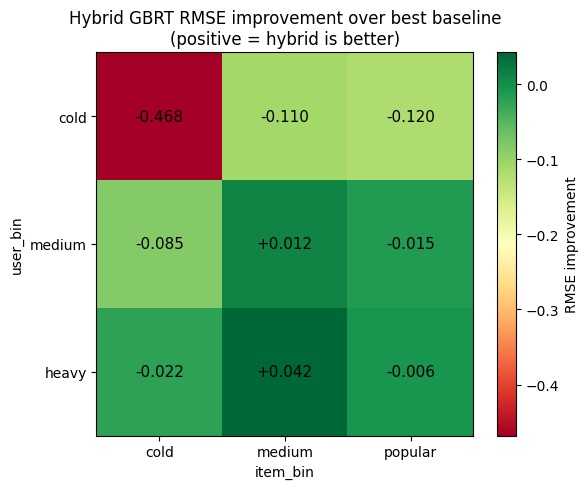

In [11]:
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(hybrid_gain, cmap='RdYlGn', aspect='auto')
ax.set_xticks(range(len(ITEM_BINS))); ax.set_xticklabels(ITEM_BINS)
ax.set_yticks(range(len(USER_BINS))); ax.set_yticklabels(USER_BINS)
ax.set_xlabel('item_bin'); ax.set_ylabel('user_bin')
ax.set_title('Hybrid GBRT RMSE improvement over best baseline\n(positive = hybrid is better)')
for ui in range(len(USER_BINS)):
    for ii in range(len(ITEM_BINS)):
        val = hybrid_gain[ui, ii]
        txt = f'{val:+.3f}' if not np.isnan(val) else 'n/a'
        ax.text(ii, ui, txt, ha='center', va='center', color='black', fontsize=11)
fig.colorbar(im, ax=ax, label='RMSE improvement')
fig.tight_layout()
fig.savefig(RESULTS_DIR / 'cold_start_grid_heatmap.png', dpi=150)
plt.show()

## Reading the results

Three things to check after running this notebook:

1. **Does content-based dominate the cold-item bin?** Look at the item-bin plot — content's bar at `cold` should be among the lowest, while SVD/NeuMF's bars at `cold` should be tall (high RMSE).
2. **Does the hybrid win in every cell?** Look at the heatmap — every cell should have a positive value (green). If a cell is red, the hybrid is *worse* than the best baseline in that region, which is a defensible limitation to discuss in the report.
3. **Are the gains statistically significant?** Look at `cold_start_significance.csv` — `**` (p < 0.01) entries are the strong claims. Bins where the hybrid is not significantly better than the best baseline should be noted honestly.

These three observations populate the report's new §7.3 Cold-Start Analysis section.